In [54]:
pip install --upgrade gensim

In [55]:
import gensim.downloader as api
print("Loading pre-trained GloVe model...")
model = api.load("glove-wiki-gigaword-50")

Loading pre-trained GloVe model...


In [56]:
import gensim.downloader as api
import numpy as np

print("Loading pre-trained GloVe model...")
model = api.load("glove-wiki-gigaword-50")

semantic_classes = {
    "Gender": {
        "raw_pairs": [
            ("king", "queen"),
            ("man", "woman"),
            ("prince", "princess"),
            ("actor", "actress"),
            ("husband", "wife")
        ]
    },
    "Past_Tense": {
        "raw_pairs": [
            ("bring", "brought"),
            ("get", "got"),
            ("like", "liked"),
            ("write", "wrote"),
            ("go", "went")
        ]
    },
    "Singular_Plural": {
        "raw_pairs": [
            ("louse", "lice"),
            ("goose", "geese"),
            ("child", "children"),
            ("mouse", "mice"),
            ("person", "people")
        ]
    },
    "Country_Capital": {
        "raw_pairs": [
            ("france", "paris"),
            ("japan", "tokyo"),
            ("poland", "warsaw"),
            ("germany", "berlin"),
            ("italy", "rome")
        ]
    },
    "Comparative_Superlative": {
        "raw_pairs": [
            ("big", "biggest"),
            ("small", "smallest"),
            ("fast", "fastest"),
            ("strong", "strongest"),
            ("happy", "happiest")
        ]
    },
    "Tool_User": {
        "raw_pairs": [
            ("camera", "photographer"),
            ("keyboard", "programmer"),
            ("brush", "painter"),
            ("microphone", "singer"),
            ("hammer", "carpenter")
        ]
    },
    "Job_Workplace": {
        "raw_pairs": [
            ("teacher", "school"),
            ("doctor", "hospital"),
            ("chef", "restaurant"),
            ("pilot", "airport"),
            ("farmer", "farm")
        ]
    },
    "Animal_Sound": {
        "raw_pairs": [
            ("dog", "bark"),
            ("cat", "meow"),
            ("cow", "moo"),
            ("sheep", "baa"),
            ("duck", "quack")
        ]
    },
    "Object_Material": {
        "raw_pairs": [
            ("table", "wood"),
            ("bottle", "glass"),
            ("ring", "gold"),
            ("shirt", "cotton"),
            ("statue", "marble")
        ]
    },
    "Vehicle_Fuel": {
        "raw_pairs": [
            ("car", "gasoline"),
            ("truck", "diesel"),
            ("ship", "oil"),
            ("train", "electricity"),
            ("rocket", "hydrogen")
        ]
    }
}

words = []
for class_name, data in semantic_classes.items():
  for w1, w2 in data["raw_pairs"]:
    words.extend([w1, w2])

embedding_matrix = np.array([model[w.lower()] for w in words])

Loading pre-trained GloVe model...


In [57]:
normalized_embedding_matrix = (
    (embedding_matrix - np.mean(embedding_matrix, axis=0)) /
    np.std(embedding_matrix, axis=0)
)

U, Sigma, VT = np.linalg.svd(normalized_embedding_matrix)
Sigma_full = np.zeros((embedding_matrix.shape[0], embedding_matrix.shape[1]))
np.fill_diagonal(Sigma_full, Sigma)
Principal_components = U @ Sigma_full

## Global PCA Chart

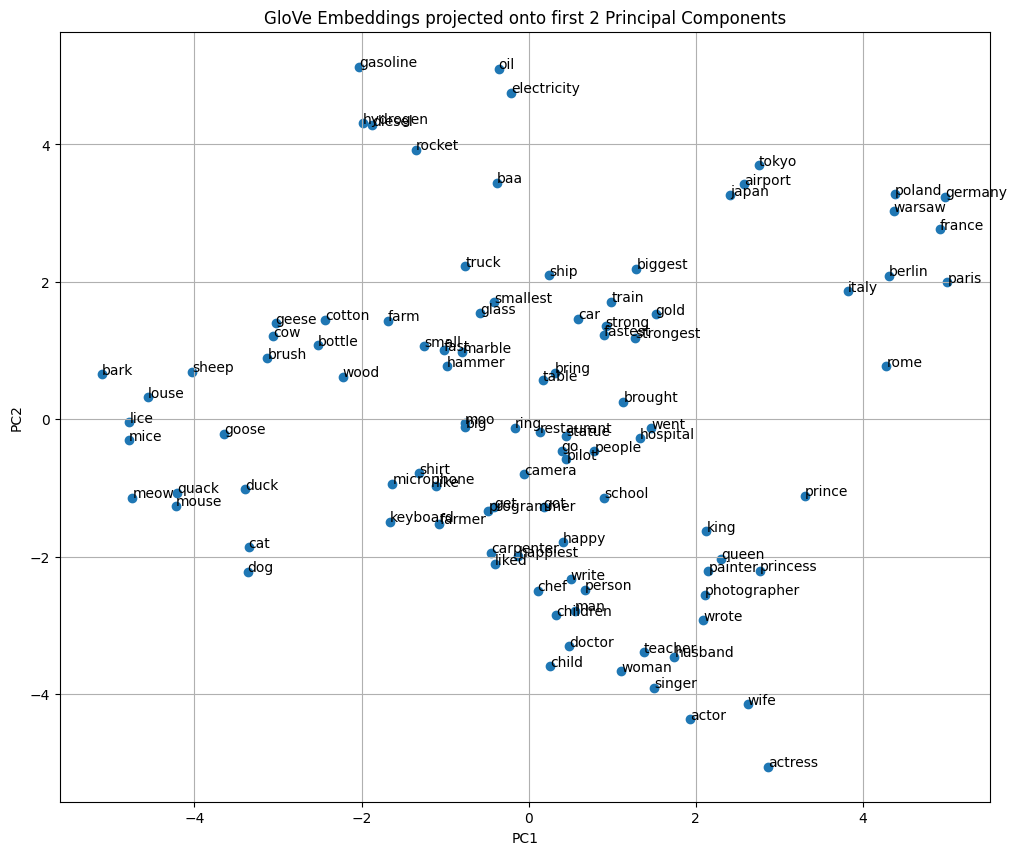

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

X = Principal_components[:, 0]
Y = Principal_components[:, 1]
plt.scatter(X, Y)

for i, word in enumerate(words):
  plt.text(X[i], Y[i], word)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("GloVe Embeddings projected onto first 2 Principal Components")
plt.grid(True)

plt.show()

In [59]:
word_to_coords = {
    word: (Principal_components[i][0], Principal_components[i][1])
    for i, word in enumerate(words)
}

for class_name, data in semantic_classes.items():
  data["words"] = []
  for w1, w2 in data["raw_pairs"]:
    data["words"].extend([w1, w2])

  data["embedding_matrix"] = np.array([model[w.lower()] for w in data["words"]])

  mean_val = np.mean(data["embedding_matrix"], axis=0)
  std_val = np.std(data["embedding_matrix"], axis=0)

  data["normalized_embedding_matrix"] = (data["embedding_matrix"] - mean_val) / std_val

  U, Sigma, VT = np.linalg.svd(data["normalized_embedding_matrix"])

  data["U"] = U
  data["Sigma"] = Sigma
  data["VT"] = VT

  data["Sigma_full"] = np.zeros(
      (
          data["embedding_matrix"].shape[0],
          data["embedding_matrix"].shape[1]
      )
  )

  np.fill_diagonal(data["Sigma_full"], data["Sigma"])
  data["Principal_components"] = data["U"] @ data["Sigma_full"]

  data["X"] = data["Principal_components"][:, 0]
  data["Y"] = data["Principal_components"][:, 1]

##Separate PCA charts


Class name: Gender


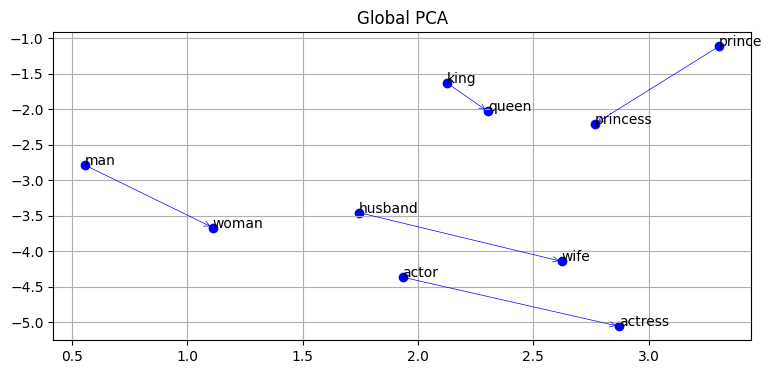

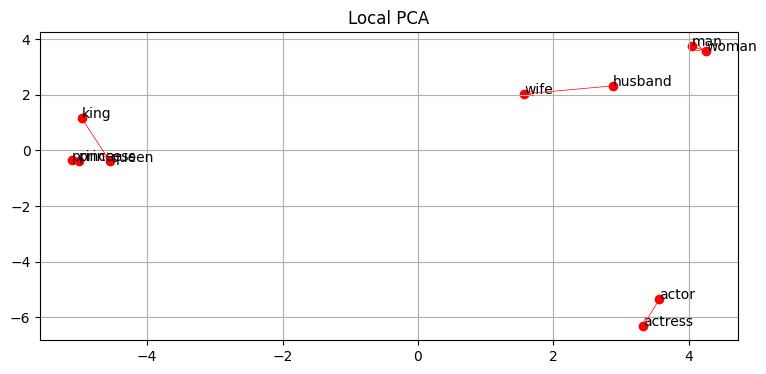


Class name: Past_Tense


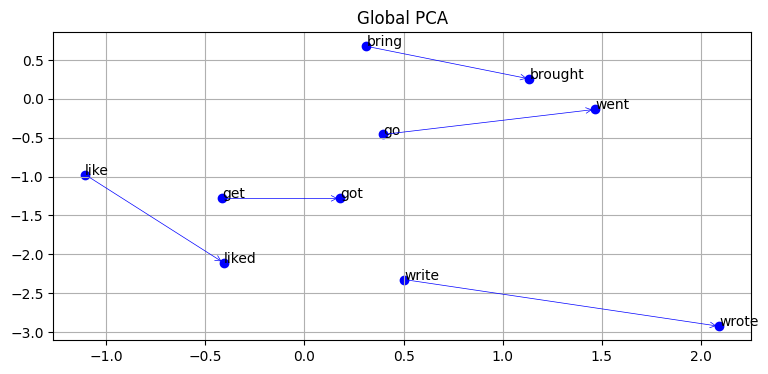

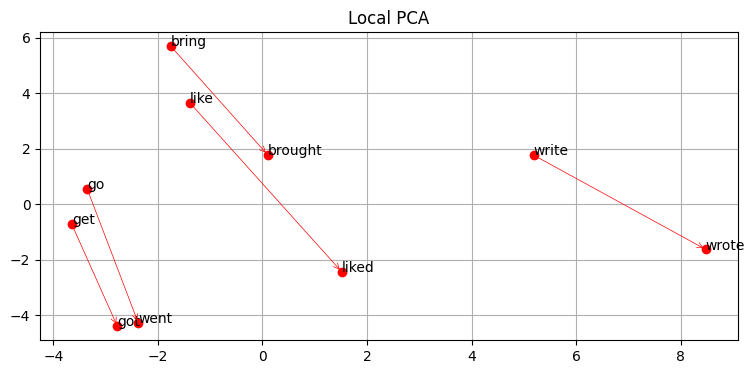


Class name: Singular_Plural


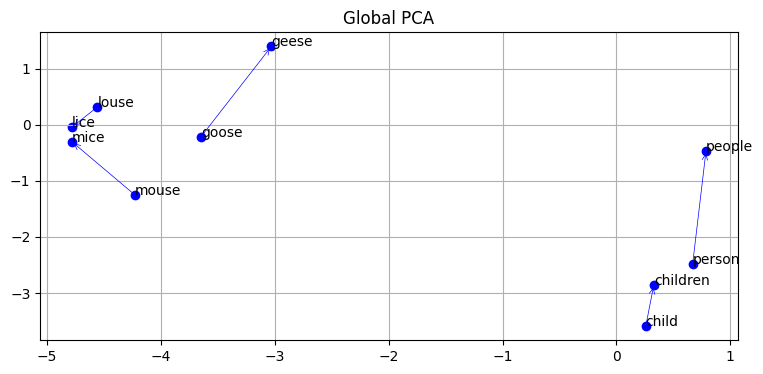

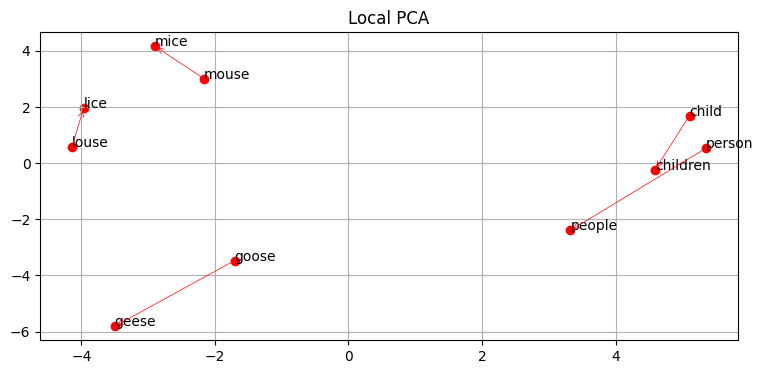


Class name: Country_Capital


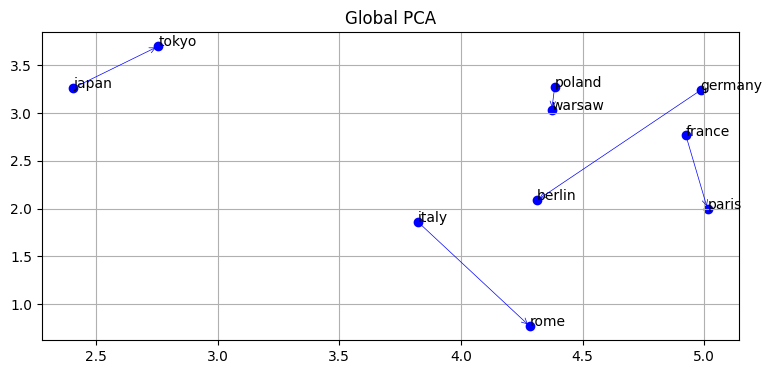

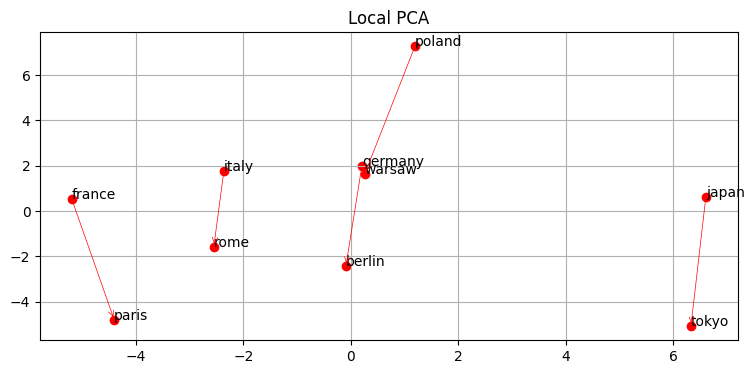


Class name: Comparative_Superlative


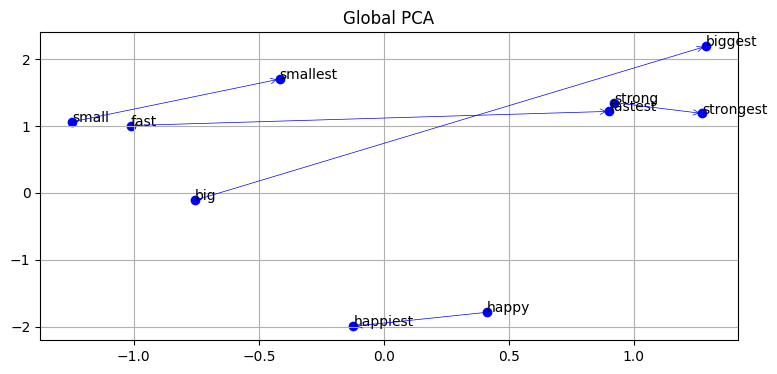

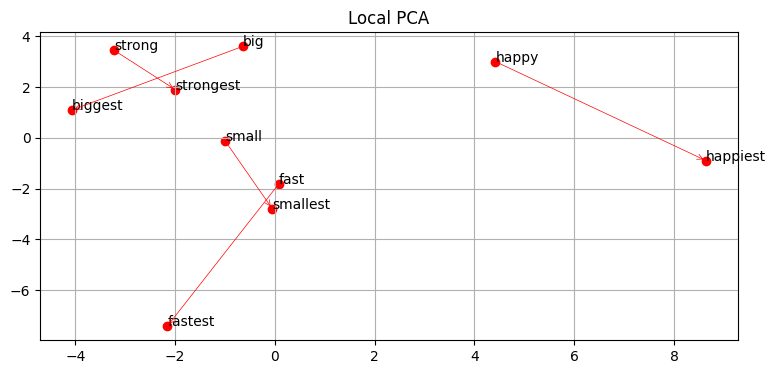


Class name: Tool_User


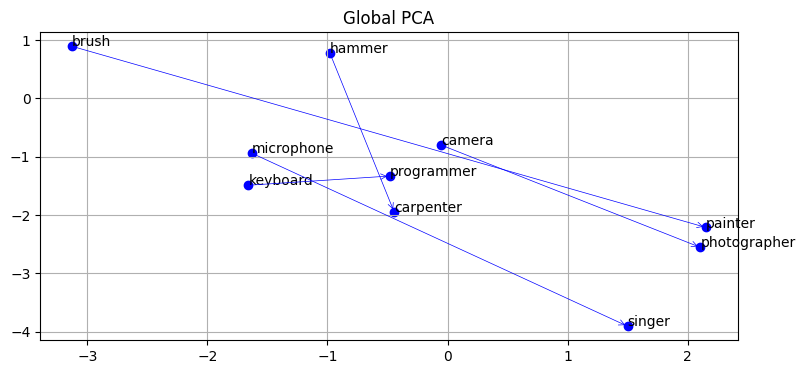

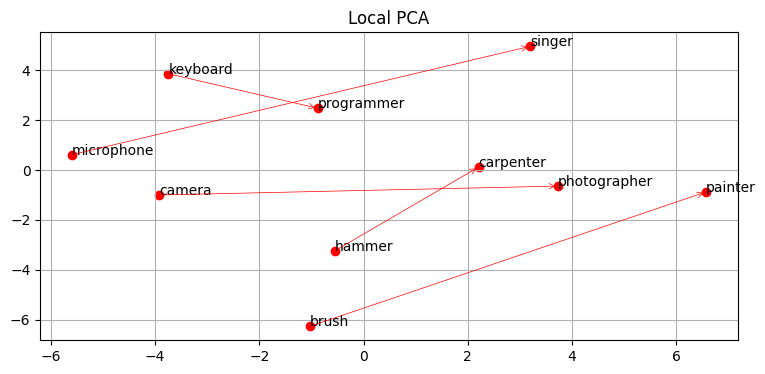


Class name: Job_Workplace


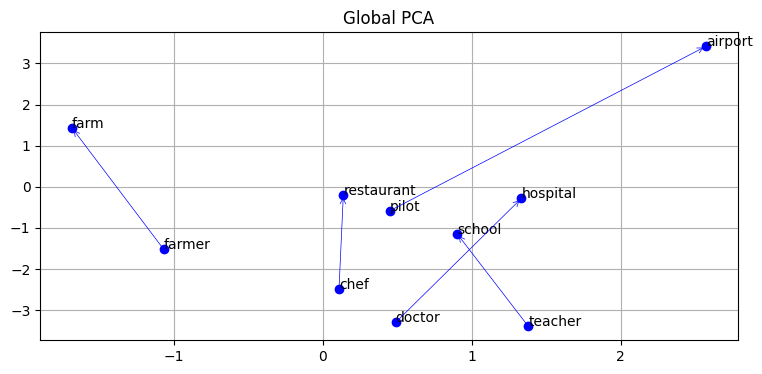

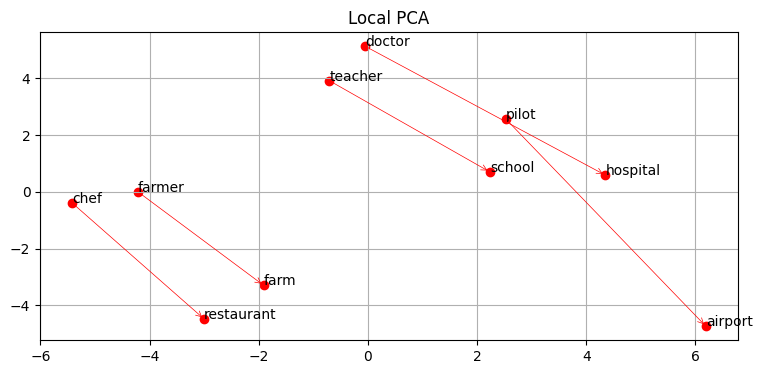


Class name: Animal_Sound


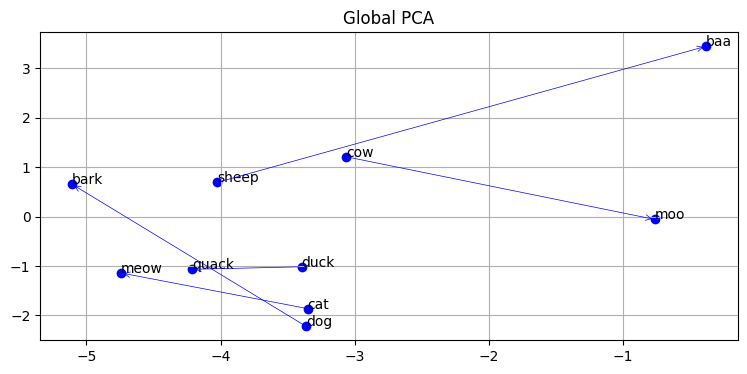

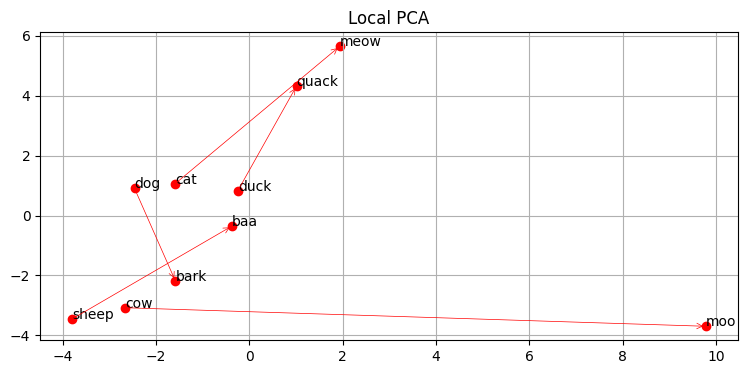


Class name: Object_Material


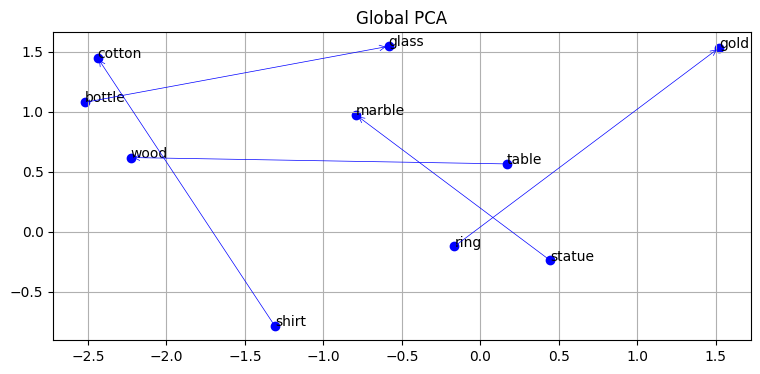

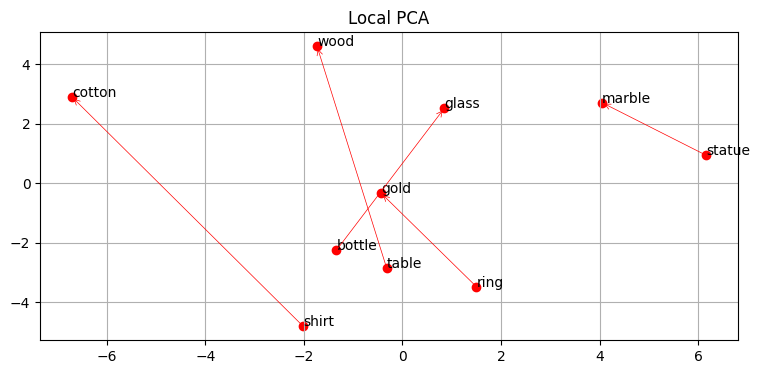


Class name: Vehicle_Fuel


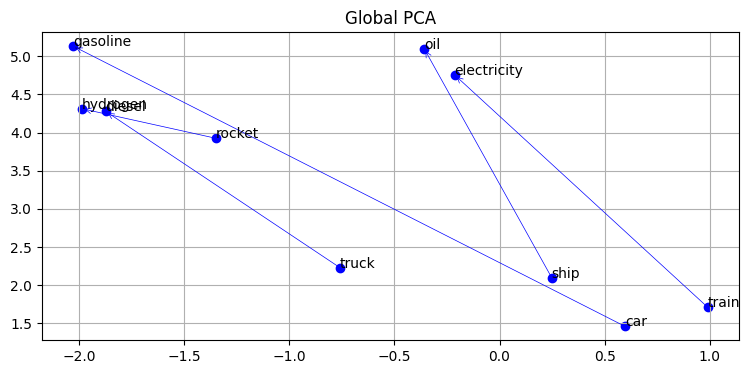

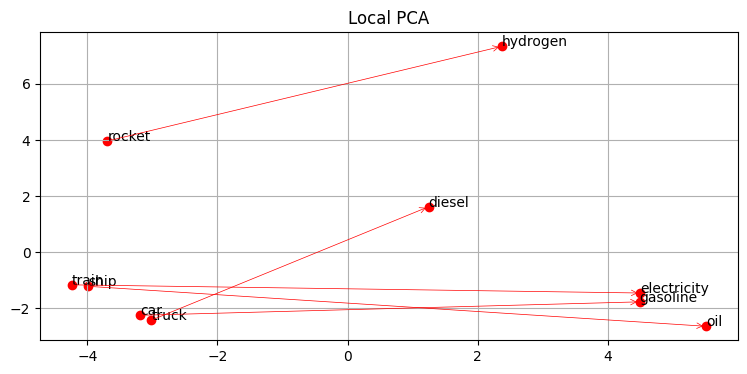

In [60]:
for class_name, data in semantic_classes.items():

  # Global PCA chart

  print(f"\nClass name: {class_name}")
  plt.figure(figsize=(9, 4))

  for w1, w2 in data["raw_pairs"]:
    x1, y1 = word_to_coords[w1]
    x2, y2 = word_to_coords[w2]

    plt.scatter([x1, x2], [y1, y2], color="blue")
    plt.text(x1, y1, w1)
    plt.text(x2, y2, w2)

    plt.annotate('', xy=(x2, y2), xytext=(x1, y1),
                 arrowprops=dict(arrowstyle="->", color="blue", lw=0.5))

  plt.title("Global PCA")
  plt.grid(True)
  plt.show()


  # Local PCA chart

  plt.figure(figsize=(9, 4))

  local_coords = {
      word: (data["X"][i], data["Y"][i])
      for i, word in enumerate(data["words"])
  }

  for word, (x, y) in local_coords.items():
    plt.scatter(x, y, color="red")
    plt.text(x, y, word)

  for w1, w2 in data["raw_pairs"]:
    if w1 in local_coords and w2 in local_coords:
      x1, y1 = local_coords[w1]
      x2, y2 = local_coords[w2]
      plt.annotate('', xy=(x2, y2), xytext=(x1, y1),
                   arrowprops=dict(arrowstyle="->", color="red", lw=0.5))

  plt.title("Local PCA")
  plt.grid(True)
  plt.show()

## PCA and Semantic Space Analysis

### Global vs. Local PCA
The visualizations show that **Local PCA** preserves semantic vector relationships much better than **Global PCA**.

- **Global PCA** projects all 100 words from 10 diverse categories into a shared 2D space. Since PCA maximizes overall variance, the projection emphasizes broad conceptual differences between categories, while subtle semantic relations become distorted.
- **Local PCA** is computed separately for each semantic class using only related words. By removing unrelated variance, it captures the internal semantic structure more effectively and produces clearer vector patterns.

### Do the Visualizations Capture Semantic Differences?
Yes, especially for relationships governed by strong linear transformations.

- Classes such as **Gender** and **Country_Capital** show highly parallel arrow structures, indicating consistent semantic transformations.
- However, PCA is a **linear dimensionality reduction method**, so it struggles with non-linear or context-dependent relationships, leading to skewed or inconsistent arrows.

### Class-by-Class Behavior

| Behavior Level | Classes | Observations |
|---|---|---|
| **Well-Behaved** | Gender, Country_Capital, Past_Tense, Comparative_Superlative | Strong parallelism and consistent vector directions. |
| **Moderately Behaved** | Vehicle_Fuel, Animal_Sound, Job_Workplace | Clear structure, but arrow lengths vary due to contextual differences. |
| **Poorly Behaved** | Object_Material, Tool_User, Singular_Plural | Chaotic patterns caused by polysemy and varied semantic contexts. |

### Summary
**Captured well:**  
- Grammatical and systematic semantic relationships  
- Consistent linear transformations

**Captured poorly:**  
- Context-dependent or ambiguous relationships  
- Semantic relations affected by polysemy

Overall, GloVe embeddings represent rigid semantic relationships with relatively stable vector directions, while looser real-world associations lack a consistent geometric structure.

## Embedding Arithmetics

For first two pairs $(A, B), (C, D)$ in each semantic class we perform $\tilde D = B - A + C$ and print top $5$ most similar keys in the GloVe dataset.

We will `use most_similar` method witch according to [documentation](https://radimrehurek.com/gensim/models/keyedvectors.html#gensim.models.keyedvectors.WordEmbeddingsKeyedVectors.most_similar$0) compute cosine similiarity, i.e.

$$
  \cos(w_1, w_2) = \frac{\langle w_1, w_2\rangle}{\|w_1\|\|w_2\|} \in [-1, 1].
$$

In [61]:
for class_name, data in semantic_classes.items():
  pair_1 = data["raw_pairs"][0]
  pair_2 = data["raw_pairs"][1]

  A, B = pair_1[0], pair_1[1]
  C, D = pair_2[0], pair_2[1]

  print(f"\nClass name: {class_name}")
  print(f"Equation: {B} - {A} + {C} = ? (Expected: {D})")

  closest_neighbors = model.most_similar(positive=[B, C], negative=[A], topn=5)
  data["arithmetic_results"] = {
          "formula": f"{B} - {A} + {C}",
          "expected": D,
          "top_5": closest_neighbors
      }

  for rank, (word, similarity) in enumerate(closest_neighbors, 1):
    print(f"  {rank}. {word} (Similarity: {similarity:.4f})")


Class name: Gender
Equation: queen - king + man = ? (Expected: woman)
  1. woman (Similarity: 0.8947)
  2. girl (Similarity: 0.8490)
  3. her (Similarity: 0.7932)
  4. boy (Similarity: 0.7824)
  5. she (Similarity: 0.7701)

Class name: Past_Tense
Equation: brought - bring + get = ? (Expected: got)
  1. when (Similarity: 0.8903)
  2. had (Similarity: 0.8869)
  3. got (Similarity: 0.8765)
  4. turned (Similarity: 0.8754)
  5. he (Similarity: 0.8654)

Class name: Singular_Plural
Equation: lice - louse + goose = ? (Expected: geese)
  1. moose (Similarity: 0.7066)
  2. beaver (Similarity: 0.6639)
  3. raccoon (Similarity: 0.6587)
  4. duck (Similarity: 0.6546)
  5. pimples (Similarity: 0.6387)

Class name: Country_Capital
Equation: paris - france + japan = ? (Expected: tokyo)
  1. tokyo (Similarity: 0.9234)
  2. shanghai (Similarity: 0.8370)
  3. japanese (Similarity: 0.7904)
  4. osaka (Similarity: 0.7831)
  5. beijing (Similarity: 0.7480)

Class name: Comparative_Superlative
Equation: bi

## Discussion: Embedding Arithmetics

GloVe is a static embedding model, meaning every word has a single fixed vector regardless of context (e.g., "keyboard" shares the same representation for computer keyboard and a musical instrument).

Mathematically, GloVe counts global word co-occurrences $(X_{ij})$ and optimizes a weighted least-squares objective function:
\begin{equation}
  \sum_{i, j} f(X_{ij})\|\langle w_i, w_j\rangle + b_j + b_j - \log X_{ij}\|_2^2
\end{equation}

This architecture forces the dot product of two word vectors to estimate their global co-occurrence log-probability. While this builds a highly linear semantic space capable of complex arithmetic $(B + A - C)$, it introduces explicit limits:

What is captured (Successes): Highly stable, cross-cultural, and structural relationships. Classes like **Gender** (queen - king + man = woman, Rank 1) and **Country_Capital** (paris - france + japan = tokyo, Rank 1) succeed perfectly because their relational shifts align along a clean, universal geometric axis. Even near-misses like **Comparative_Superlative** (returning largest instead of smallest) prove that the model correctly isolates semantic scales.

What is not captured (Failures): Polysemy and abstract morphology. Arithmetics in operation for **Tool_User** class failed, becouse the word "keyboard" has been recognized as a music instrment in the first place.

Similarly, in **Animal_Sound**, the operation bark - dog + cat yielded botanical terms (twigs, deciduous) because the static vector for "bark" is overwhelmingly dominated by its corpus frequency as tree bark rather than a canine sound.
